In [ ]:
############ LOAD in custom packages ################
import sys
import os
import pandas as pd
import numpy as np
import importlib
from fastdtw import dtw
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt


############ LOAD in custom packages ################

project_root = os.path.join(os.getcwd(), "..") # Get path of the project 
sys.path.append(project_root) # Add project root to sys.path for script usage

# Import and reload (optional) custom scripts
from scripts import paths
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables
from scripts import feature_selection as fs
from scripts import clustering as cl

importlib.reload(paths)
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)
importlib.reload(cl)

# Filepaths
brighten_dir = paths.DATA
results_dir = paths.RESULTS
demo_dir = paths.DEMO
charts_dir = paths.CHARTS

################ DEFINE column variables from data ###################
from scripts.variables import id_columns, df_names, all_daily_cols, daily_v2_weather
from scripts.variables import phq2_cols, phq9_cols, weekly_cols, passive_cols, baseline_cols, created_cols, drop_cols_for_feature_selection
from scripts.variables import keep_weather, drop_corr_cols_v1, drop_corr_cols_v2
demo_df = pd.read_csv(os.path.join(demo_dir, f'demographics_clean.csv'))
demographic_vars = [col for col in demo_df.columns if col!='num_id' and 'Unnamed' not in col]
print(demographic_vars)
id_columns.append('idx')
time_cols = []

############## Define and load dfs ###########
dfs = {}
for name in df_names:
	for split in ['trainval']:
		dfs[name] = pd.read_csv(os.path.join(brighten_dir, f'{name}_{split}_imputed.csv'))
		# display(dfs[name].head())


['phq9_1_base', 'phq9_2_base', 'phq9_3_base', 'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base', 'phq9_8_base', 'phq9_9_base', 'screen_1', 'screen_2', 'screen_3', 'screen_4', 'phq9_category', 'bin_clin', 'participant_id', 'gender', 'education', 'working', 'income_satisfaction', 'income_lastyear', 'marital_status', 'race', 'age_category']


Run on: Fri 29 May 2026, 02:19PM


DATAFRAME: v1_day
In df there are 189 subjects.


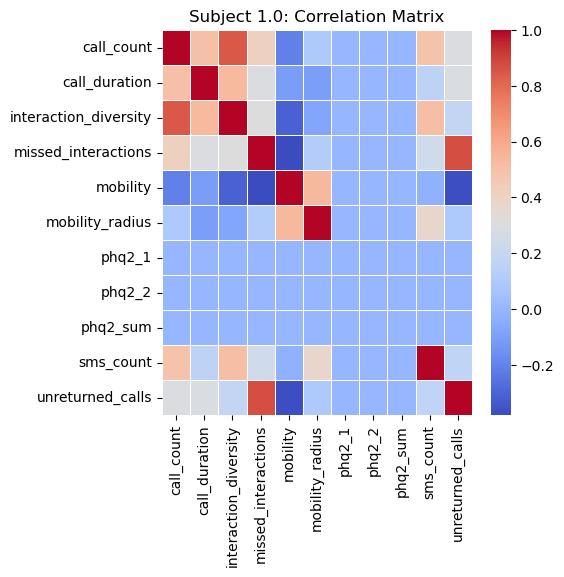

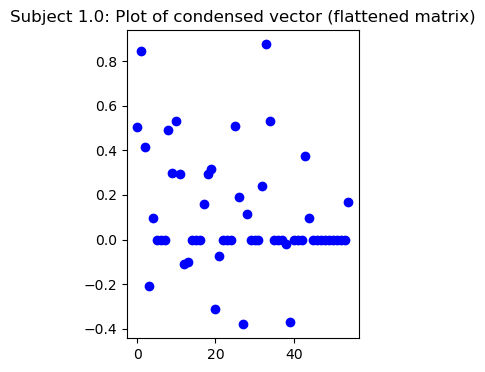

189 subs with symptom matrices
189 filled condensed arrays


DATAFRAME: v1_week
In df there are 180 subjects.


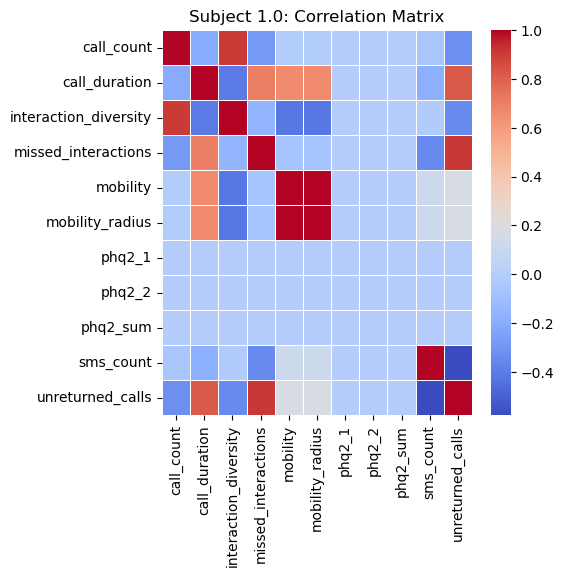

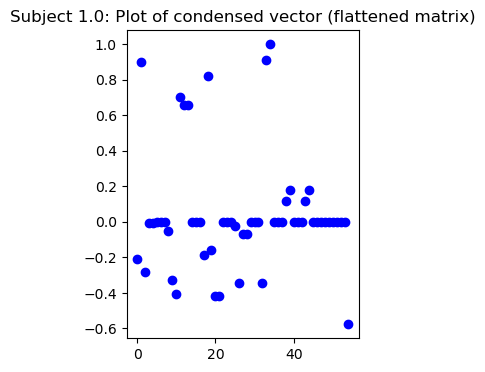

180 subs with symptom matrices
180 filled condensed arrays


DATAFRAME: v2_day
In df there are 158 subjects.


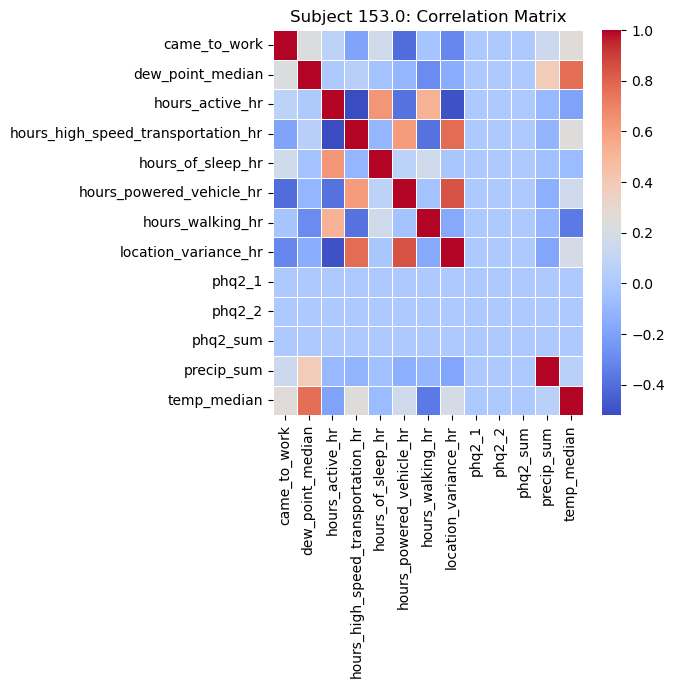

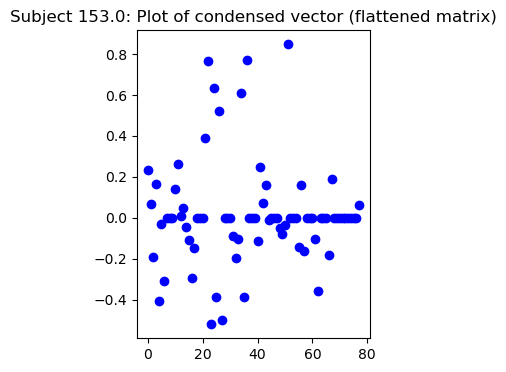

158 subs with symptom matrices
158 filled condensed arrays


DATAFRAME: v2_week
In df there are 147 subjects.


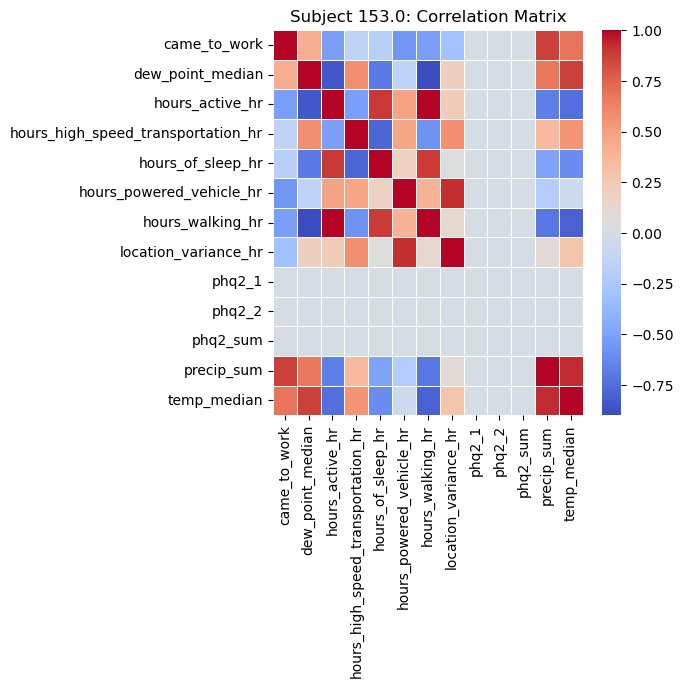

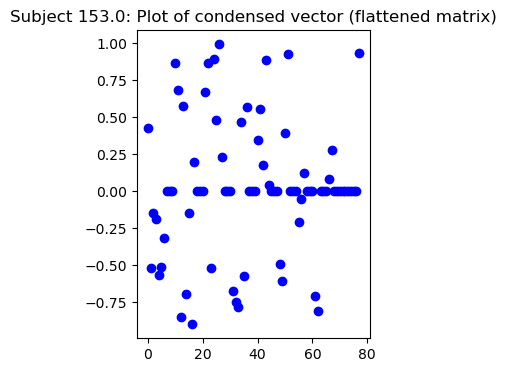

147 subs with symptom matrices
147 filled condensed arrays


In [ ]:
#### Take the average of each subject's symptom correlation and use it to make clusters of variables
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))


symptom_matrices_df_dict = {}
flattened_matrices_df_dict = {}
target_cols = phq2_cols+phq9_cols
non_pca_cols = {}
# Create dicts of all subjects' correlation matrices
for name in ['v1_day','v1_week','v2_day','v2_week']:
	df = dfs[name].copy()
	df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

	# take out time cols, nonnumeric cols, baseline cols
	df['num_id'] = pd.to_numeric(df['num_id'])
	numeric_cols = df.select_dtypes(include=('int64','float64')).columns.to_list()
	drop_nonnumeric_cols = [col for col in df.columns if col not in numeric_cols]
	drop_dup_dumb_cols = [col for col in df.columns if '.1' in col or '.2' in col or '.3' in col or 'Unnamed' in col]
	drop_baseline_cols = [col for col in df.columns if any(item in col for item in baseline_cols)]
	drop_time_cols = [col for col in df.columns if any(item in col for item in ['dt','date','day','week','month','season'])]
	drop_non_hr_cols = [col for col in df.columns if f'{col}_hr' in df.columns]
	# Too correlated or overlapping cols or fully missing cols
	drop_fs_cols = [col for col in df.columns if col in drop_cols_for_feature_selection]
	# weekly cols 
	df_clean = df.drop(columns=[col for col in df.columns if col in drop_nonnumeric_cols+drop_dup_dumb_cols+drop_baseline_cols+drop_time_cols+drop_non_hr_cols+drop_fs_cols])
	
	drop_weekly = [col for col in df_clean.columns if col not in all_daily_cols and col != 'num_id']
	df_clean2 = df_clean.drop(columns=[col for col in df_clean.columns if col in drop_weekly])

		

	print(f'\n\nDATAFRAME: {name}')
	symptom_matrix_dict, flattened_matrix_dict = fs.make_symptom_matrices(df_clean2, ignore_cols=['num_id'], num_to_plot=1)
	symptom_matrices_df_dict[name] = symptom_matrix_dict
	flattened_matrices_df_dict[name] = flattened_matrix_dict



Run on: Fri 29 May 2026, 02:19PM


/Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/pipeline/../scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/pipeline/../scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/pipeline/../scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/pipeline/../scripts/

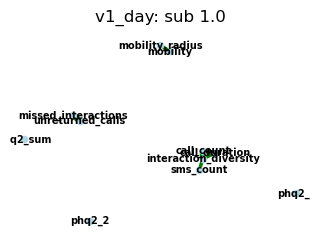

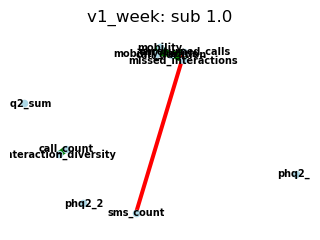

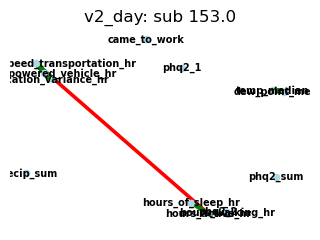

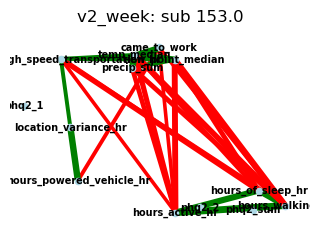

In [ ]:
############### Plot individual networks of symptom matrices #################
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

for name, df_dict in symptom_matrices_df_dict.items():
	count=0
	for sub, corr_matrix in df_dict.items():
		if count<1:
			fs.plot_network(corr_matrix, title=f'{name}: sub {sub}')
			count=+1

In [56]:
# Double check where 'labels' are for columns
symptom_matrices_df_dict['v1_week'][list(symptom_matrices_df_dict['v1_week'].keys())[0]].index

Index(['call_count', 'call_duration', 'interaction_diversity',
       'missed_interactions', 'mobility', 'mobility_radius', 'phq2_1',
       'phq2_2', 'phq2_sum', 'sms_count', 'unreturned_calls'],
      dtype='str')

### Ok so temp mean and dew point IQR keep having relatively high correlations with the target variables, so we'll keep these, and drop the rest of the weather variables. Humidity also does but since it's highyl correlated with temp, we'll keep it out. 

# SENSORS PCA

Run on: Fri 29 May 2026, 02:31PM
v1_day
(11, 11) variables included


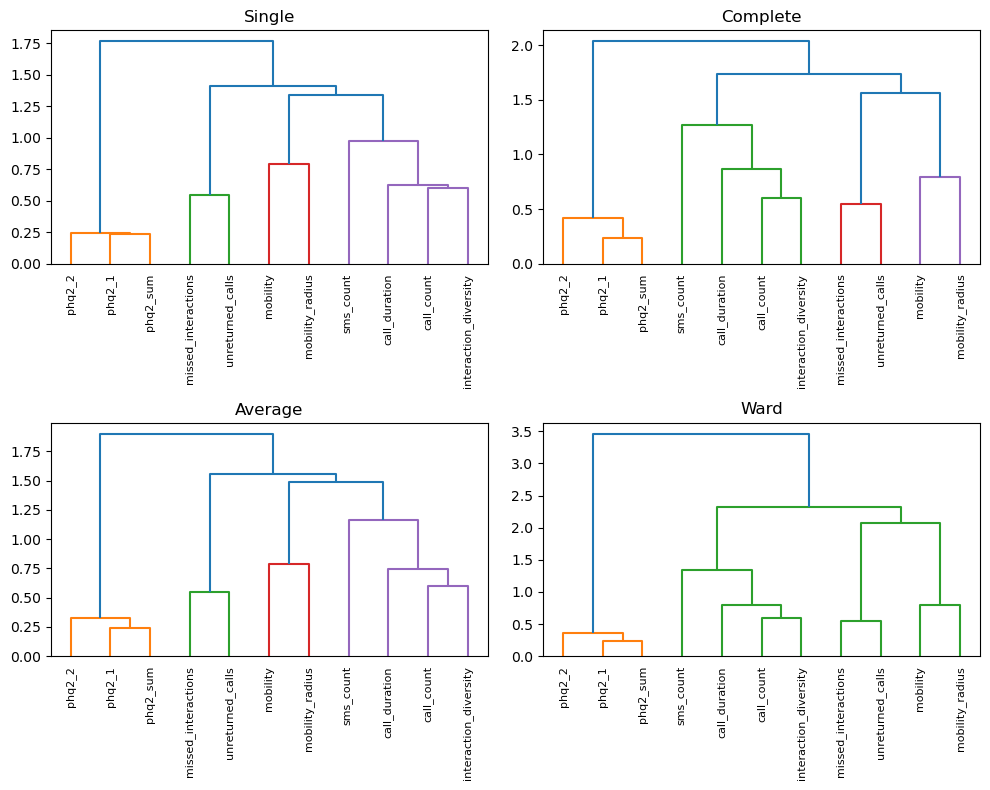

v1_week
(11, 11) variables included


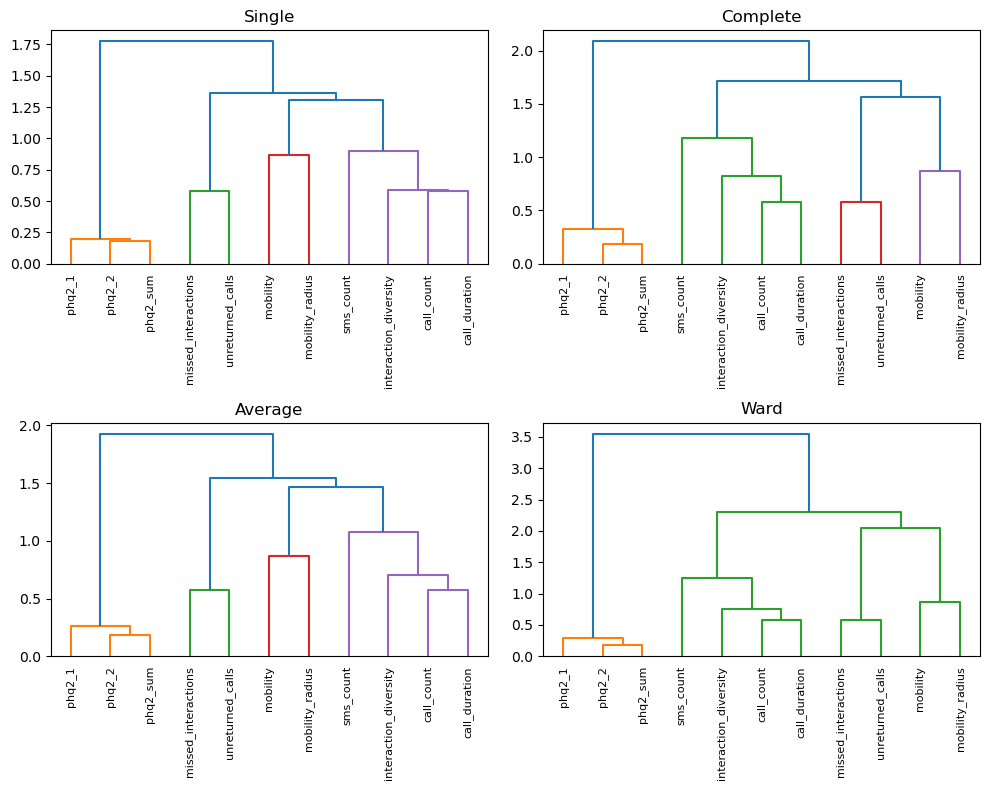

v2_day
(13, 13) variables included


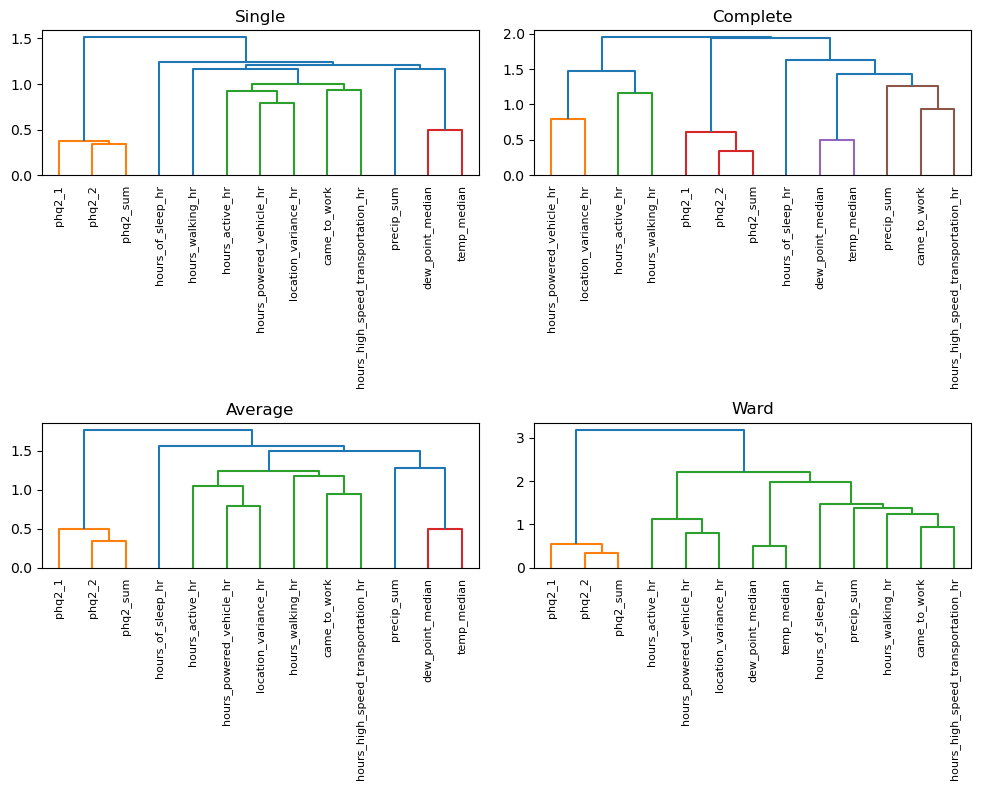

v2_week
(13, 13) variables included


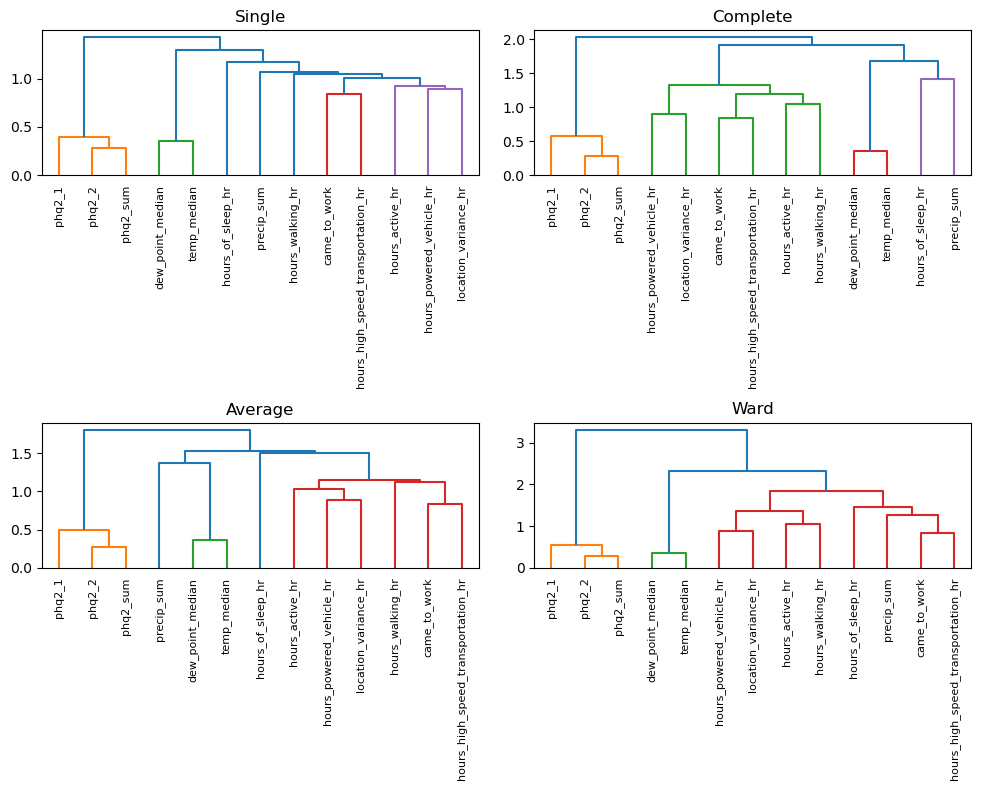

In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

## Plot options
for name, df in symptom_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(df)
	fs.plot_hier_agg(avg_matrix, df[list(df.keys())[0]].index, is_dict=False, group_title=f'{name}') # 3, ward


### Mark down best fits:
* v1_day -> 4, average
* v2_day -> 6, complete
* v1_week -> 4, average
* v2_week ->6, average

In [ ]:
################# Create cluster_dict of Variables + Cluster Labels ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
importlib.reload(fs)

sensor_clust_dict = {}
# clust_dict['v1_day'] = v1_day_clust_dict
for name, dictionary in symptom_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(dictionary)
	print(f'For {name}...')
	if 'v1_day' in name:
		sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=4, linkage='average', is_dict=False)
	if 'v2_day' in name:
	   sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=6, linkage='complete', is_dict=False)
	if 'v1_week' in name:
		sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=4, linkage='average', is_dict=False)
	if 'v2_week' in name:
	   sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=6, linkage='complete', is_dict=False)

Run on: Fri 29 May 2026, 02:31PM
For v1_day...
For cluster 0, columns: ['call_count', 'call_duration', 'interaction_diversity', 'sms_count']
For cluster 1, columns: ['mobility', 'mobility_radius']
For cluster 2, columns: ['missed_interactions', 'unreturned_calls']
For cluster 3, columns: ['phq2_1', 'phq2_2', 'phq2_sum']
For v1_week...
For cluster 0, columns: ['call_count', 'call_duration', 'interaction_diversity', 'sms_count']
For cluster 1, columns: ['mobility', 'mobility_radius']
For cluster 2, columns: ['missed_interactions', 'unreturned_calls']
For cluster 3, columns: ['phq2_1', 'phq2_2', 'phq2_sum']
For v2_day...
For cluster 0, columns: ['came_to_work', 'hours_high_speed_transportation_hr', 'precip_sum']
For cluster 1, columns: ['hours_active_hr', 'hours_walking_hr']
For cluster 2, columns: ['phq2_1', 'phq2_2', 'phq2_sum']
For cluster 3, columns: ['hours_of_sleep_hr']
For cluster 4, columns: ['hours_powered_vehicle_hr', 'location_variance_hr']
For cluster 5, columns: ['dew_point_m

In [71]:
v1_day_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v1_day_trainval_imputed.csv'))
v1_week_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v1_week_trainval_imputed.csv'))
v2_day_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v2_day_trainval_imputed.csv'))
v2_week_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v2_week_trainval_imputed.csv'))


In [ ]:
################# Apply Trainval Clustering Solution to Train AND TEST* (blind, not fit) ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
importlib.reload(fs)
dfs_pca = {}
dfs_pca_dict = {}
test_pca = {}
test_pca_dict = {}

for name in df_names:
	print(f'\nFor {name}')

	df = dfs[name].copy()
	df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
	dfs_pca[name], dfs_pca_dict[name] = fs.pca_on_clusters(df, sensor_clust_dict[name], n_clusters=6) #n_clusters = number shown, so choose max
	
	# Make test df pca with the same clusters as defined by trainval, so we can use for prediction
	test_df=pd.read_csv(os.path.join(brighten_dir, f'{name}_test_imputed.csv'))
	test_df = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]
	test_pca[name], test_pca_dict[name] = fs.pca_on_clusters(test_df, sensor_clust_dict[name], n_clusters=6) #n_clusters = number shown, so choose max


Run on: Fri 29 May 2026, 02:31PM

For v1_day
Cols applied for cluster 0: ['call_duration', 'interaction_diversity', 'call_count', 'sms_count']
Cols applied for cluster 1: ['mobility', 'mobility_radius']
Cols applied for cluster 2: ['missed_interactions', 'unreturned_calls']
Cols applied for cluster 3: ['phq2_1', 'phq2_2', 'phq2_sum']
Skipping cluster 4: No variables assigned.
Skipping cluster 5: No variables assigned.
Cols applied for cluster 0: ['call_duration', 'interaction_diversity', 'call_count', 'sms_count']
Cols applied for cluster 1: ['mobility', 'mobility_radius']
Cols applied for cluster 2: ['missed_interactions', 'unreturned_calls']
Cols applied for cluster 3: ['phq2_1', 'phq2_2', 'phq2_sum']
Skipping cluster 4: No variables assigned.
Skipping cluster 5: No variables assigned.

For v2_day
Cols applied for cluster 0: ['precip_sum', 'came_to_work', 'hours_high_speed_transportation_hr']
Cols applied for cluster 1: ['hours_walking_hr', 'hours_active_hr']
Cols applied for cluster

In [ ]:
# Create PCA loadings for Trainval DFs
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# v1_day
dfs_pca_dict['v1_day'][0]['name'] = 'pc_social'              # call_count, call_duration, interaction_diversity, sms_count
dfs_pca_dict['v1_day'][1]['name'] = 'pc_mobility'           # mobility, mobility_radius
dfs_pca_dict['v1_day'][2]['name'] = 'pc_missed_calls'       # missed_interactions, unreturned_calls
dfs_pca_dict['v1_day'][3]['name'] = 'pc_phq2'               # phq2_1, phq2_2, phq2_sum

# v1_week
dfs_pca_dict['v1_week'][0]['name'] = 'pc_social'             # call_count, call_duration, interaction_diversity, sms_count
dfs_pca_dict['v1_week'][1]['name'] = 'pc_mobility'          # mobility, mobility_radius
dfs_pca_dict['v1_week'][2]['name'] = 'pc_missed_calls'      # missed_interactions, unreturned_calls
dfs_pca_dict['v1_week'][3]['name'] = 'pc_phq2'              # phq2_1, phq2_2, phq2_sum

# v2_day
dfs_pca_dict['v2_day'][0]['name'] = 'pc_commute'            # came_to_work, hours_high_speed_transportation_hr, precip_sum
dfs_pca_dict['v2_day'][1]['name'] = 'pc_active_mobility'    # hours_active_hr, hours_walking_hr
dfs_pca_dict['v2_day'][2]['name'] = 'pc_phq2'               # phq2_1, phq2_2, phq2_sum
dfs_pca_dict['v2_day'][3]['name'] = 'pc_sleep'              # hours_of_sleep_hr
dfs_pca_dict['v2_day'][4]['name'] = 'pc_vehicle_location'   # hours_powered_vehicle_hr, location_variance_hr
dfs_pca_dict['v2_day'][5]['name'] = 'pc_temp'               # dew_point_median, temp_median

# v2_week
dfs_pca_dict['v2_week'][0]['name'] = 'pc_commute'           # came_to_work, hours_active_hr, hours_high_speed_transportation_hr, hours_walking_hr
dfs_pca_dict['v2_week'][1]['name'] = 'pc_phq2'              # phq2_1, phq2_2, phq2_sum
dfs_pca_dict['v2_week'][2]['name'] = 'pc_vehicle_location'  # hours_powered_vehicle_hr, location_variance_hr
dfs_pca_dict['v2_week'][3]['name'] = 'pc_temp'              # dew_point_median, temp_median
dfs_pca_dict['v2_week'][4]['name'] = 'pc_sleep'             # hours_of_sleep_hr
dfs_pca_dict['v2_week'][5]['name'] = 'pc_precip'            # precip_sum

for name in df_names:
	df = dfs[name].copy()
	dfs_pca[name] = fs.merge_df_via_cluster_pca_dict(df, dfs_pca_dict[name], on_columns=['num_id', 'day'])
	dfs_pca[name].to_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'), index=False)
	print(f'Saved {name}_trainval_pca.csv')



Run on: Fri 29 May 2026, 02:32PM
Saved v1_day_trainval_pca.csv
Saved v2_day_trainval_pca.csv
Saved v1_week_trainval_pca.csv
Saved v2_week_trainval_pca.csv


In [78]:
# Create PCA loadings for Test DFs
# But its' not getting visualized anywhere
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# v1_day
test_pca_dict['v1_day'][0]['name'] = 'pc_social'              # call_count, call_duration, interaction_diversity, sms_count
test_pca_dict['v1_day'][1]['name'] = 'pc_mobility'           # mobility, mobility_radius
test_pca_dict['v1_day'][2]['name'] = 'pc_missed_calls'       # missed_interactions, unreturned_calls
test_pca_dict['v1_day'][3]['name'] = 'pc_phq2'               # phq2_1, phq2_2, phq2_sum

# v1_week
test_pca_dict['v1_week'][0]['name'] = 'pc_social'             # call_count, call_duration, interaction_diversity, sms_count
test_pca_dict['v1_week'][1]['name'] = 'pc_mobility'          # mobility, mobility_radius
test_pca_dict['v1_week'][2]['name'] = 'pc_missed_calls'      # missed_interactions, unreturned_calls
test_pca_dict['v1_week'][3]['name'] = 'pc_phq2'              # phq2_1, phq2_2, phq2_sum

# v2_day
test_pca_dict['v2_day'][0]['name'] = 'pc_commute'            # came_to_work, hours_high_speed_transportation_hr, precip_sum
test_pca_dict['v2_day'][1]['name'] = 'pc_active_mobility'    # hours_active_hr, hours_walking_hr
test_pca_dict['v2_day'][2]['name'] = 'pc_phq2'               # phq2_1, phq2_2, phq2_sum
test_pca_dict['v2_day'][3]['name'] = 'pc_sleep'              # hours_of_sleep_hr
test_pca_dict['v2_day'][4]['name'] = 'pc_vehicle_location'   # hours_powered_vehicle_hr, location_variance_hr
test_pca_dict['v2_day'][5]['name'] = 'pc_temp'               # dew_point_median, temp_median

# v2_week
test_pca_dict['v2_week'][0]['name'] = 'pc_commute'           # came_to_work, hours_active_hr, hours_high_speed_transportation_hr, hours_walking_hr
test_pca_dict['v2_week'][1]['name'] = 'pc_phq2'              # phq2_1, phq2_2, phq2_sum
test_pca_dict['v2_week'][2]['name'] = 'pc_vehicle_location'  # hours_powered_vehicle_hr, location_variance_hr
test_pca_dict['v2_week'][3]['name'] = 'pc_temp'              # dew_point_median, temp_median
test_pca_dict['v2_week'][4]['name'] = 'pc_sleep'             # hours_of_sleep_hr
test_pca_dict['v2_week'][5]['name'] = 'pc_precip'            # precip_sum

for name in df_names:
	test_df_scaled = pd.read_csv(os.path.join(brighten_dir, f'{name}_test_imputed.csv'))
	test_pca[name] = fs.merge_df_via_cluster_pca_dict(test_df_scaled, test_pca_dict[name], on_columns=['num_id', 'day'])
	test_pca[name].to_csv(os.path.join(brighten_dir, f'{name}_test_pca.csv'), index=False) 
	print(f'Saved {name}_test_pca.csv')





Run on: Fri 29 May 2026, 02:33PM
Saved v1_day_test_pca.csv
Saved v2_day_test_pca.csv
Saved v1_week_test_pca.csv
Saved v2_week_test_pca.csv


### View some individual networks

In [79]:
############ Plot subjects' individual networks of PCs ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

for name in df_names:
	dfs_pca = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))

	fixed_positions_v1_day = {
		'pc_social':        (1, 1),
		'pc_mobility':     (1, 2),
		'pc_missed_calls': (1, 3),
		'pc_phq2':         (2, 1)
	}

	fixed_positions_v1_week = {
		'pc_social':        (1, 1),
		'pc_mobility':     (1, 2),
		'pc_missed_calls': (1, 3),
		'pc_phq2':         (2, 1)
	}

	fixed_positions_v2_day = {
		'pc_commute':         (1, 1),
		'pc_active_mobility': (1, 2),
		'pc_phq2':            (1, 3),
		'pc_sleep':           (2, 1),
		'pc_vehicle_location':(2, 2),
		'pc_temp':            (2, 3)
	}

	fixed_positions_v2_week = {
		'pc_commute':         (1, 1),
		'pc_phq2':            (1, 2),
		'pc_vehicle_location':(1, 3),
		'pc_temp':            (2, 1),
		'pc_sleep':           (2, 2),
		'pc_precip':          (2, 3)
	}

	count, count2, count3, count4 = 0, 0, 0, 0
	
	cols=[col for col in df.columns.to_list() if 'pc_' in col]
	for sub in df['num_id'].unique():
		sub_df = df[df['num_id']==sub]
		corr_matrix=sub_df[cols].corr()
		if sub_df.shape[0] > 8:
			if count<7:
				if 'v1_day' in name:
					try:
						fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v1_day, display=True)
						count+=1
					except Exception as e:
						print(f"Error on {sub}:, {e}")
			if count2<7:
				if 'v2_day' in name:
					try:
						fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v2_day, display=True)
						count2+=1
					except Exception as e:
						print(f"Error on {sub}:, {e}")					

			if count3<7:
				if 'v1_week' in name:
					try:
						fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v1_week, display=True)
						count3+=1
					except Exception as e:
						print(f"Error on {sub}:, {e}")

			if count4<7:
				if 'v2_week' in name:
					try:
						fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v2_week, display=True)
						count4+=1
					except Exception as e:
						print(f"Error on {sub}:, {e}")


Run on: Fri 29 May 2026, 02:33PM


## Run if you want to save ALL network graph outputs.

In [ ]:
############ Plot subjects' individual networks of PCs ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
importlib.reload(fs)

for name in df_names:

	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))
	save_dir = os.path.join(charts_dir, 'subject_pc_networks2_test', name)
	os.makedirs(save_dir, exist_ok=True)

	fixed_positions_v1_day = {
		'pc_social':        (1, 1),
		'pc_mobility':     (1, 2),
		'pc_missed_calls': (1, 3),
		'pc_phq2':         (2, 1)
	}

	fixed_positions_v1_week = {
		'pc_social':        (1, 1),
		'pc_mobility':     (1, 2),
		'pc_missed_calls': (1, 3),
		'pc_phq2':         (2, 1)
	}

	fixed_positions_v2_day = {
		'pc_commute':         (1, 1),
		'pc_active_mobility': (1, 2),
		'pc_phq2':            (1, 3),
		'pc_sleep':           (2, 1),
		'pc_vehicle_location':(2, 2),
		'pc_temp':            (2, 3)
	}

	fixed_positions_v2_week = {
		'pc_commute':         (1, 1),
		'pc_phq2':            (1, 2),
		'pc_vehicle_location':(1, 3),
		'pc_temp':            (2, 1),
		'pc_sleep':           (2, 2),
		'pc_precip':          (2, 3)
	}
	count, count2, count3, count4 = 0, 0, 0, 0
	
	cols=[col for col in df.columns.to_list() if 'pc_' in col]
	for sub in df['num_id'].unique():
		sub_df = df[df['num_id']==sub]
		sub_save_dir = os.path.join(save_dir, f'{sub}_pc_network.png')
		corr_matrix=sub_df[cols].corr()
		if sub_df.shape[0] > 8:
			if 'v1_day' in name:
				try:
					fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v1_day, display=False, save_dir=sub_save_dir)
				except Exception as e:
						print(f"Error on {sub}:, {e}")

			if 'v1_week' in name:
				try:
					fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v1_week, display=False, save_dir=sub_save_dir)
				except Exception as e:
						print(f"Error on {sub}:, {e}")
			if 'v2_day' in name:
				try:
					fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v2_day, display=False, save_dir=sub_save_dir)
				except Exception as e:
						print(f"Error on {sub}:, {e}")
			if 'v2_week' in name:
				try:
					fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v2_week, display=False, save_dir=sub_save_dir)
				except Exception as e:
						print(f"Error on {sub}:, {e}")



Run on: Fri 29 May 2026, 02:44PM


## Checking for collinearity


Run on: Fri 29 May 2026, 02:46PM


For v1_day:


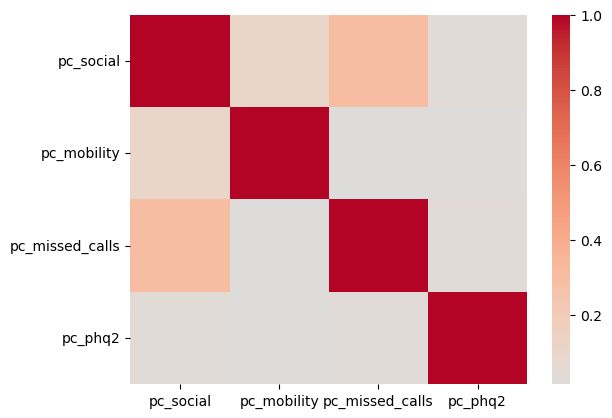



For v2_day:


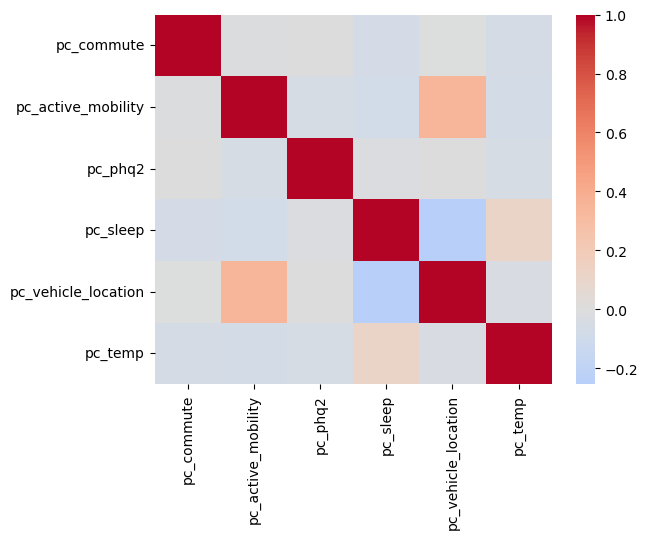



For v1_week:


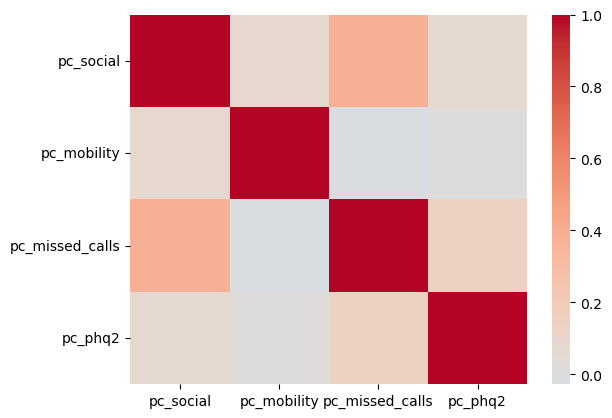



For v2_week:


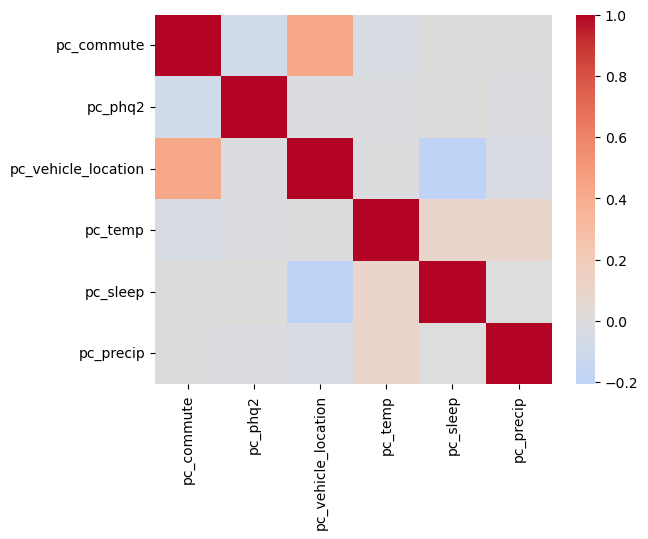

In [5]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

for name in df_names:
	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))
	print(f'\n\nFor {name}:')
	numeric_cols = [col for col in df.columns.to_list() if 'pc_' in col]
	sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
	plt.show()

We can see that our features are successfull not correlated, except phq2 and phq9, which is expected, and in most cases, phq2 won't be used to predict phq9. 